# Data Import

In this step, the required Python libraries are imported, and all Blinkit datasets are loaded into Pandas DataFrames. The inventory data is stored in two separate CSV files, which are combined into a single dataset using `pd.concat()` for further analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("../data/raw/blinkit_customers.csv")
orders = pd.read_csv("../data/raw/blinkit_orders.csv")
order_items = pd.read_csv("../data/raw/blinkit_order_items.csv")
products = pd.read_csv("../data/raw/blinkit_products.csv")

# Combine both inventory files
inventory = pd.concat([
    pd.read_csv("../data/raw/blinkit_inventory.csv"),
    pd.read_csv("../data/raw/blinkit_inventoryNew.csv")
], ignore_index=True)

delivery = pd.read_csv("../data/raw/blinkit_delivery_performance.csv")
marketing = pd.read_csv("../data/raw/blinkit_marketing_performance.csv")
feedback = pd.read_csv("../data/raw/blinkit_customer_feedback.csv")

In [2]:
inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 93277 entries, 0 to 93276
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   product_id      93277 non-null  int64
 1   date            93277 non-null  str  
 2   stock_received  93277 non-null  int64
 3   damaged_stock   93277 non-null  int64
dtypes: int64(3), str(1)
memory usage: 2.8 MB


In [3]:
inventory.head()

,product_id,date,stock_received,damaged_stock
0,153019,17-03-2023,4,2
1,848226,17-03-2023,4,2
2,965755,17-03-2023,1,0
3,39154,17-03-2023,4,0
4,34186,17-03-2023,3,2


## Missing Value Check

This step checks for missing (null) values in each column of the inventory dataset.

In [4]:
inventory.isnull().sum()

product_id        0
date              0
stock_received    0
damaged_stock     0
dtype: int64

Duplicate Records

In [5]:
inventory.duplicated().sum()

np.int64(7359)

In [6]:
inventory.dtypes

product_id        int64
date                str
stock_received    int64
damaged_stock     int64
dtype: object

In [7]:
inventory.columns

Index(['product_id', 'date', 'stock_received', 'damaged_stock'], dtype='str')

In [8]:
inventory["date"].head(10)

0    17-03-2023
1    17-03-2023
2    17-03-2023
3    17-03-2023
4    17-03-2023
5    17-03-2023
6    17-03-2023
7    17-03-2023
8    17-03-2023
9    17-03-2023
Name: date, dtype: str

## Date Format Conversion

The `date` column is converted from text format to the `datetime` data type. Since the combined inventory dataset contains dates in multiple formats, `format="mixed"` is used to correctly parse all values. Setting `dayfirst=True` ensures that dates are interpreted in day-month-year order.

In [9]:
inventory["date"] = pd.to_datetime(
    inventory["date"],
    format="mixed",
    dayfirst=True
)

In [10]:
inventory["date"].head()
inventory["date"].isna().sum()

np.int64(0)

In [11]:
inventory["date"].tail(20)

93257   1-11-24
93258   1-11-24
93259   1-11-24
93260   1-11-24
93261   1-11-24
93262   1-11-24
93263   1-11-24
93264   1-11-24
93265   1-11-24
93266   1-11-24
93267   1-11-24
93268   1-11-24
93269   1-11-24
93270   1-11-24
93271   1-11-24
93272   1-11-24
93273   1-11-24
93274   1-11-24
93275   1-11-24
93276   1-11-24
Name: date, dtype: datetime64[us]

In [12]:
inventory = inventory.drop_duplicates()

In [13]:
inventory["Day"] = inventory["date"].dt.day

In [14]:
inventory["product_id"].nunique()

268

In [15]:
inventory["stock_received"].sum()

np.int64(166011)

In [16]:
inventory["damaged_stock"].sum()

np.int64(81290)

In [17]:
inventory["available_stock"] = inventory["stock_received"] - inventory["damaged_stock"]

In [18]:
inventory["damage_percent"] = (
    inventory["damaged_stock"] /
    inventory["stock_received"]
)*100

In [19]:
inventory["damage_percent"].mean()

np.float64(inf)

## Outlier Detection Using Box Plot

A box plot is used to identify the distribution of the `stock_received` values and detect potential outliers. Outliers are unusually high or low values that may affect the analysis and should be reviewed before further processing.

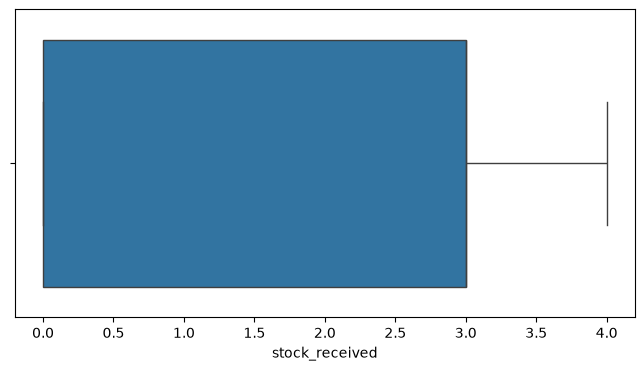

In [20]:
plt.figure(figsize=(8,4))
sns.boxplot(x=inventory["stock_received"])
plt.show()

## Outlier Detection for Damaged Stock

This box plot is used to visualize the distribution of the `damaged_stock` values and identify any potential outliers. Detecting outliers helps understand unusual inventory damage patterns and ensures more reliable analysis.

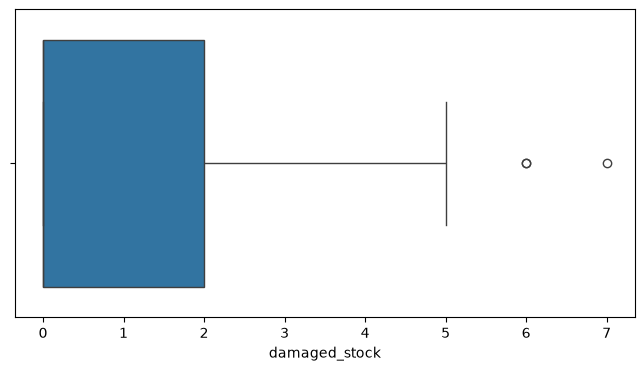

In [21]:
plt.figure(figsize=(8,4))
sns.boxplot(x=inventory["damaged_stock"])
plt.show()

In [22]:
print(inventory.columns.tolist())

['product_id', 'date', 'stock_received', 'damaged_stock', 'Day', 'available_stock', 'damage_percent']


In [23]:
inventory["Month"] = inventory["date"].dt.month_name()

In [24]:
inventory.groupby("Month")["stock_received"].sum()

Month
April        16365
August       16382
December      9150
February      8323
January       9135
July         15926
June         16258
March        12949
May          16905
November     10562
October      17351
September    16705
Name: stock_received, dtype: int64

In [25]:
customers.tail()

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
2495,48002829,Daksh Mandal,varkeymohammed@example.com,919587731286,"28/42, Venkataraman Ganj, Kishanganj-360157",Mumbai,45238,2024-01-25,Inactive,17,754.33
2496,57392064,Lavanya Jain,deshpandeom@example.com,916137420258,"391, Edwin Path, Korba 202726",Udupi,688100,2024-06-23,Regular,4,1540.81
2497,71688530,Umang Dash,gokhalenicholas@example.org,917595275963,"151, Parmer Ganj\nLoni 906431",Kavali,528749,2024-03-18,Regular,1,1541.22
2498,89051578,Zinal Natarajan,vyasfrado@example.com,911994009448,"H.No. 172, Khanna Street, Pudukkottai 610564",Alwar,586734,2024-09-06,Premium,12,1185.50
2499,78738569,Eiravati Sundaram,onkar24@example.com,914320353753,"H.No. 791, Sur Path\nBally 982559",Dewas,342448,2023-05-10,Inactive,4,376.50


In [26]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        2500 non-null   int64  
 1   customer_name      2500 non-null   str    
 2   email              2500 non-null   str    
 3   phone              2500 non-null   int64  
 4   address            2500 non-null   str    
 5   area               2500 non-null   str    
 6   pincode            2500 non-null   int64  
 7   registration_date  2500 non-null   str    
 8   customer_segment   2500 non-null   str    
 9   total_orders       2500 non-null   int64  
 10  avg_order_value    2500 non-null   float64
dtypes: float64(1), int64(4), str(6)
memory usage: 215.0 KB


In [27]:
customers.describe(include="all")

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
count,2.500000e+03,2500,2500,2.500000e+03,2500,2500,2500.000000,2500,2500,2500.000000,2500.000000
unique,NaN,2491,2496,NaN,2500,316,NaN,589,4,NaN,NaN
top,NaN,Gaurang Grewal,yashoda79@example.net,NaN,"23, Nayar Path, Bihar Sharif-154625",Jalna,NaN,2024-04-22,Regular,NaN,NaN
freq,NaN,2,2,NaN,1,18,NaN,10,639,NaN,NaN
mean,4.989961e+07,NaN,NaN,9.150532e+11,NaN,NaN,497653.183200,NaN,NaN,10.491600,1102.375836
std,2.919266e+07,NaN,NaN,2.882835e+09,NaN,NaN,281167.293249,NaN,NaN,5.805533,523.043183
min,3.181300e+04,NaN,NaN,9.100132e+11,NaN,NaN,666.000000,NaN,NaN,1.000000,200.430000
25%,2.402443e+07,NaN,NaN,9.125946e+11,NaN,NaN,257079.750000,NaN,NaN,6.000000,631.817500
50%,5.000044e+07,NaN,NaN,9.150236e+11,NaN,NaN,498662.000000,NaN,NaN,10.000000,1118.650000
75%,7.595459e+07,NaN,NaN,9.176256e+11,NaN,NaN,740668.000000,NaN,NaN,16.000000,1565.400000


In [28]:
customers.head()

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,Niharika Nagi,ektataneja@example.org,912987579691,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,2023-05-13,Premium,13,451.92
1,22077605,Megha Sachar,vedant45@example.com,915123179717,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,2024-06-18,Inactive,4,825.48
2,47822591,Hema Bahri,samiazaan@example.com,910034076149,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,2024-09-25,Regular,17,1969.81
3,79726146,Zaitra Vig,ishanvi87@example.org,916264232390,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,2023-10-04,New,4,220.09
4,57102800,Januja Verma,atideshpande@example.org,917293526596,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,2024-03-22,Inactive,14,578.14


Missing Values

In [29]:
customers.isnull().sum()

customer_id          0
customer_name        0
email                0
phone                0
address              0
area                 0
pincode              0
registration_date    0
customer_segment     0
total_orders         0
avg_order_value      0
dtype: int64

In [30]:
(customers.isnull().sum()/len(customers))*100

customer_id          0.0
customer_name        0.0
email                0.0
phone                0.0
address              0.0
area                 0.0
pincode              0.0
registration_date    0.0
customer_segment     0.0
total_orders         0.0
avg_order_value      0.0
dtype: float64

Remove Duplicate

In [31]:
customers = customers.drop_duplicates()

In [32]:
customers.nunique()

customer_id          2500
customer_name        2491
email                2496
phone                2500
address              2500
area                  316
pincode              2494
registration_date     589
customer_segment        4
total_orders           20
avg_order_value      2487
dtype: int64

In [33]:
print(customers.columns.tolist())

['customer_id', 'customer_name', 'email', 'phone', 'address', 'area', 'pincode', 'registration_date', 'customer_segment', 'total_orders', 'avg_order_value']


In [34]:
customers["registration_date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [35]:
customers["registration_date"].head(10)

0    2023-05-13
1    2024-06-18
2    2024-09-25
3    2023-10-04
4    2024-03-22
5    2024-04-22
6    2024-09-13
7    2024-04-10
8    2023-07-04
9    2023-06-29
Name: registration_date, dtype: str

In [36]:
customers["registration_date"] = pd.to_datetime(
    customers["registration_date"],
    format="%Y-%m-%d"
)

Basic Information

In [37]:
customers["registration_date"].dtype

dtype('<M8[us]')

In [38]:
order_items.shape

(5000, 4)

In [39]:
order_items.columns.tolist()

['order_id', 'product_id', 'quantity', 'unit_price']

In [40]:
order_items.describe(include="all")

,order_id,product_id,quantity,unit_price
count,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,5.029129e+09,509974.939600,2.006800,493.157900
std,2.863533e+09,293678.307475,0.820542,298.075647
min,6.046500e+04,4452.000000,1.000000,12.320000
25%,2.531421e+09,257719.000000,1.000000,227.220000
50%,5.074378e+09,540618.000000,2.000000,448.160000
75%,7.488579e+09,747801.000000,3.000000,781.080000
max,9.998298e+09,993331.000000,3.000000,995.980000


Missing Values

In [41]:
order_items.isnull().sum()

order_id      0
product_id    0
quantity      0
unit_price    0
dtype: int64

Duplicate Records

In [42]:
order_items.duplicated().sum()

np.int64(0)

In [43]:
order_items = order_items.drop_duplicates()

In [44]:
print(order_items.columns.tolist())

['order_id', 'product_id', 'quantity', 'unit_price']


Date Features

In [45]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

In [46]:
orders["Year"] = orders["order_date"].dt.year
orders["Month"] = orders["order_date"].dt.month_name()
orders["Day"] = orders["order_date"].dt.day
orders["Weekday"] = orders["order_date"].dt.day_name()
orders["Quarter"] = orders["order_date"].dt.quarter

KPIs


In [47]:
orders["order_id"].nunique()

5000

Monthly Orders

In [48]:
orders.groupby("Month")["order_id"].count()

Month
April        479
August       536
December     268
February     252
January      270
July         500
June         480
March        371
May          539
November     295
October      501
September    509
Name: order_id, dtype: int64

Product-wise Sales

In [49]:
order_items["total_sales"] = (
    order_items["quantity"] * order_items["unit_price"]
)

In [50]:
order_items.groupby("product_id")["total_sales"] \
           .sum() \
           .sort_values(ascending=False) \
           .head(10)

product_id
51036     65212.70
34186     56464.65
880510    55182.94
557908    51830.35
264803    51790.96
739534    48733.44
18035     46509.12
883013    45534.48
349294    44868.00
112390    43899.00
Name: total_sales, dtype: float64

Product-wise Quantity

In [51]:
order_items.groupby("product_id")["quantity"] \
           .sum() \
           .sort_values(ascending=False) \
           .head(10)

product_id
51036     70
820973    68
604184    62
34186     61
992178    60
880510    58
673058    56
89084     56
123983    55
654623    55
Name: quantity, dtype: int64

Top 10 Products by Quantity

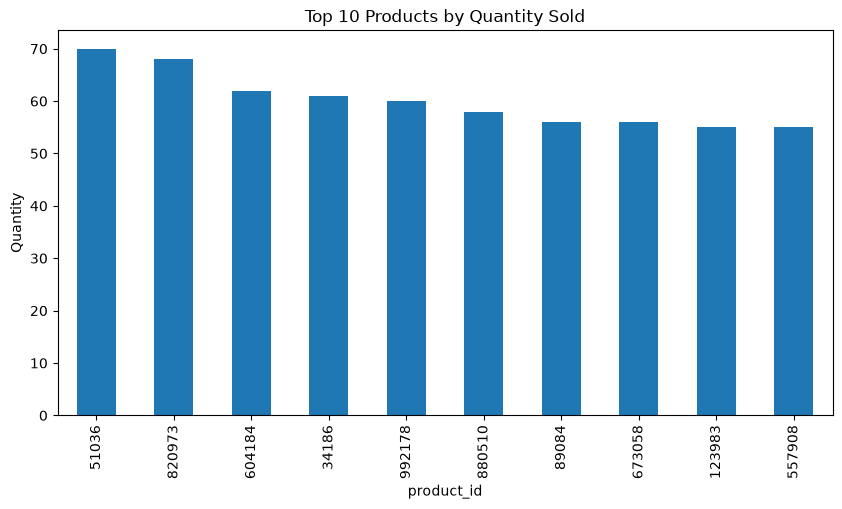

In [52]:
order_items.groupby("product_id")["quantity"] \
           .sum() \
           .nlargest(10) \
           .plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Products by Quantity Sold")
plt.ylabel("Quantity")
plt.show()

Unit Price Distribution

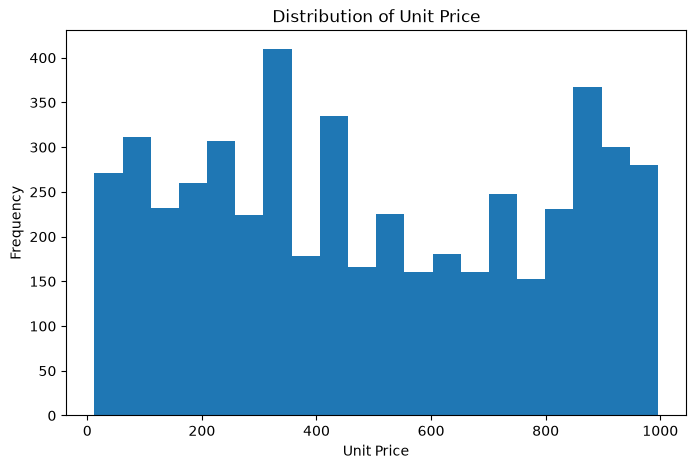

In [53]:
plt.figure(figsize=(8,5))
plt.hist(order_items["unit_price"], bins=20)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

Quantity Distribution

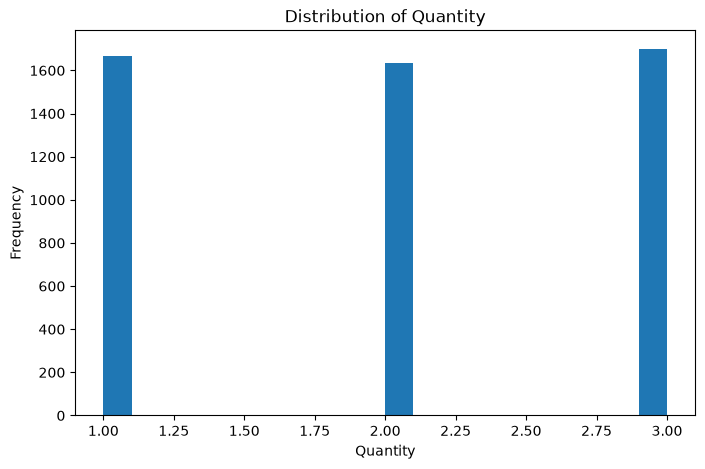

In [54]:
plt.figure(figsize=(8,5))
plt.hist(order_items["quantity"], bins=20)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

Dataset Overview

In [55]:
products.head()

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25.0,3,27,55


In [56]:
products.head()

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25.0,3,27,55


In [57]:
products.shape

(268, 10)

In [58]:
products.columns.tolist()

['product_id',
 'product_name',
 'category',
 'brand',
 'price',
 'mrp',
 'margin_percentage',
 'shelf_life_days',
 'min_stock_level',
 'max_stock_level']

Missing Values

In [59]:
products.isnull().sum()

product_id           0
product_name         0
category             0
brand                0
price                0
mrp                  0
margin_percentage    0
shelf_life_days      0
min_stock_level      0
max_stock_level      0
dtype: int64

## Duplicate Record Analysis

This step identifies duplicate records to ensure data quality.

In [60]:
products.duplicated().sum()

np.int64(0)

In [61]:
products = products.drop_duplicates()

## Category-wise Product Count

This analysis shows the number of products available in each category.

In [62]:
products["category"].value_counts()

category
Dairy & Breakfast        30
Fruits & Vegetables      27
Snacks & Munchies        27
Household Care           27
Personal Care            25
Pet Care                 25
Pharmacy                 25
Grocery & Staples        24
Cold Drinks & Juices     22
Instant & Frozen Food    20
Baby Care                16
Name: count, dtype: int64

Brand-wise Products

In [63]:
products["brand"].value_counts().head(10)

brand
Jha Group                  2
Aurora LLC                 1
Ramaswamy-Tata             1
Chadha and Sons            1
Barad and Sons             1
Sangha, Nagar and Varty    1
Doshi, Sarraf and Sama     1
Ramakrishnan-Ghose         1
Agarwal-Dhar               1
Suresh, Bose and Bajwa     1
Name: count, dtype: int64

Price Statistics

In [64]:
products["price"].describe()


count    268.000000
mean     488.356828
std      298.487200
min       12.320000
25%      226.717500
50%      442.185000
75%      779.445000
max      995.980000
Name: price, dtype: float64

Average Margin by Category

In [65]:
products.groupby("category")["price"] \
        .mean() \
        .sort_values(ascending=False)

category
Pharmacy                 599.026800
Dairy & Breakfast        569.096333
Pet Care                 546.934000
Fruits & Vegetables      546.535185
Baby Care                516.152500
Cold Drinks & Juices     500.515000
Personal Care            441.595600
Instant & Frozen Food    420.345000
Snacks & Munchies        417.106667
Household Care           403.194444
Grocery & Staples        397.357500
Name: price, dtype: float64

Most Expensive Products

In [66]:
products.sort_values(
    by="price",
    ascending=False
).head(10)

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
253,264803,Vitamins,Pharmacy,Gole-Doshi,995.98,1244.97,20.0,365,17,69
167,739534,Toilet Cleaner,Household Care,"Gera, Narang and Karpe",994.56,1326.08,25.0,365,14,59
53,883013,Eggs,Dairy & Breakfast,Chahal Group,989.88,1237.35,20.0,7,13,98
110,305754,Frozen Vegetables,Instant & Frozen Food,Mammen-Hegde,979.99,1633.32,40.0,180,22,81
75,602241,Nuts,Snacks & Munchies,Bahl-Pau,976.55,1502.38,35.0,90,12,75
112,491314,Ice Cream,Instant & Frozen Food,Banerjee Inc,973.44,1622.40,40.0,180,11,71
172,897083,Detergent,Household Care,Dutta-Halder,972.69,1296.92,25.0,365,10,100
153,18035,Dish Soap,Household Care,Ramesh Inc,968.94,1291.92,25.0,365,12,87
55,455083,Butter,Dairy & Breakfast,Dutta Inc,959.01,1198.76,20.0,7,29,63
39,880510,Bread,Dairy & Breakfast,Roy-Char,951.43,1189.29,20.0,7,29,54


Highest Margin Products

In [67]:
products.sort_values(
    by="margin_percentage",
    ascending=False
).head(10)

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
118,606256,Frozen Biryani,Instant & Frozen Food,Agate Ltd,369.28,615.47,40.0,180,16,57
106,532965,Frozen Pizza,Instant & Frozen Food,Sachdev Inc,307.23,512.05,40.0,180,20,94
109,969851,Frozen Vegetables,Instant & Frozen Food,"Kara, Sodhi and Bassi",340.66,567.77,40.0,180,27,64
108,689769,Frozen Vegetables,Instant & Frozen Food,Kothari-Datta,46.62,77.70,40.0,180,17,51
107,365132,Instant Noodles,Instant & Frozen Food,Dar-Kumar,229.38,382.30,40.0,180,19,70
124,306177,Frozen Biryani,Instant & Frozen Food,Som Inc,769.24,1282.07,40.0,180,11,54
123,621677,Frozen Biryani,Instant & Frozen Food,Sabharwal-Mital,317.80,529.67,40.0,180,15,71
125,272170,Ice Cream,Instant & Frozen Food,Purohit Group,140.80,234.67,40.0,180,10,92
110,305754,Frozen Vegetables,Instant & Frozen Food,Mammen-Hegde,979.99,1633.32,40.0,180,22,81
111,398340,Instant Noodles,Instant & Frozen Food,"Nadig, Zachariah and Soni",651.93,1086.55,40.0,180,11,56


Category Distribution Chart

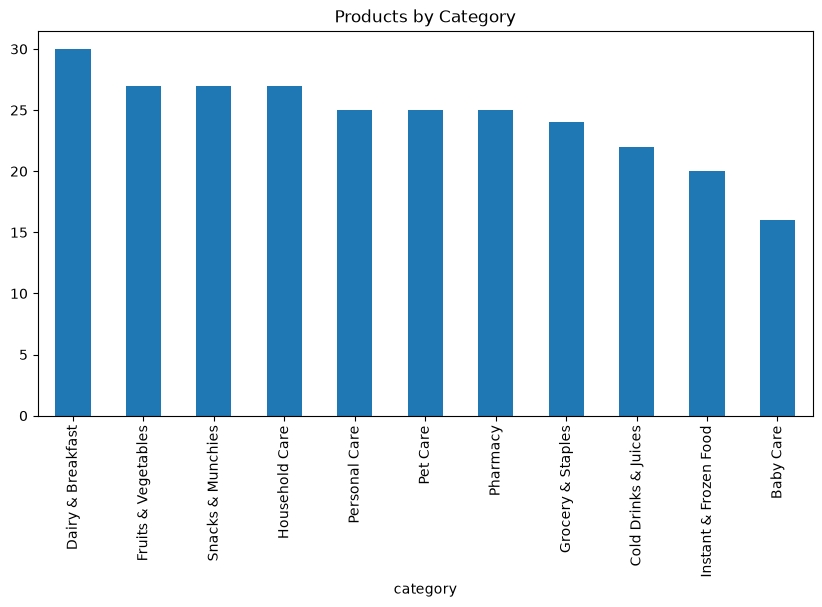

In [68]:
products["category"].value_counts().plot(
    kind="bar",
    figsize=(10,5),
    title="Products by Category"
)

plt.show()

Brand Distribution

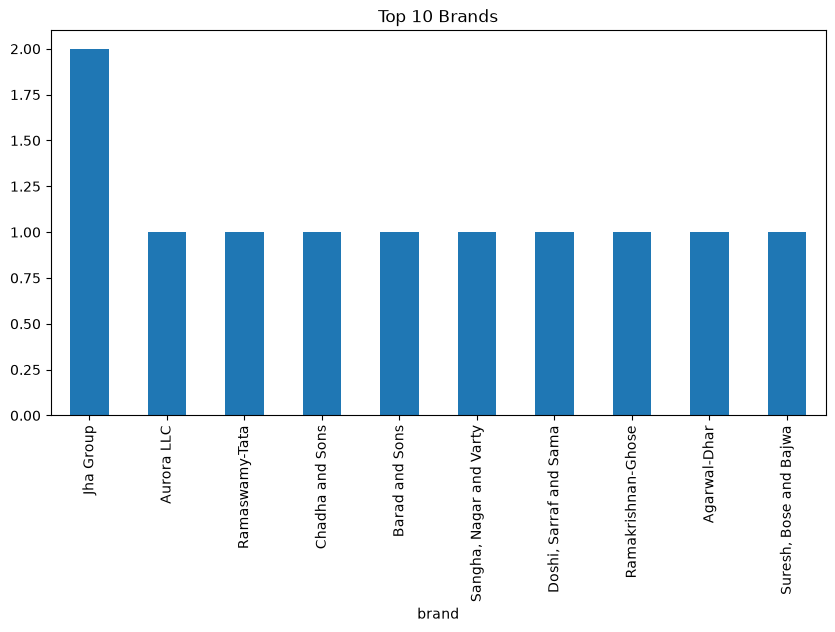

In [69]:
products["brand"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Brands"
)

plt.show()

## Delivery Performance Dataset Overview

This section explores the structure, dimensions, and summary statistics of the delivery performance dataset.

In [70]:
delivery.head()

,order_id,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status,reasons_if_delayed
0,1961864118,63230,2024-07-17 08:52:01,2024-07-17 08:47:01,-5.0,0.96,On Time,NaN
1,1549769649,14983,2024-05-28 13:25:29,2024-05-28 13:27:29,2.0,0.98,On Time,Traffic
2,9185164487,39859,2024-09-23 13:25:12,2024-09-23 13:29:12,4.0,3.83,On Time,Traffic
3,9644738826,61497,2023-11-24 16:34:56,2023-11-24 16:33:56,-1.0,2.76,On Time,NaN
4,5427684290,84315,2023-11-20 05:17:39,2023-11-20 05:18:39,1.0,2.63,On Time,Traffic


In [71]:
delivery.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               5000 non-null   int64  
 1   delivery_partner_id    5000 non-null   int64  
 2   promised_time          5000 non-null   str    
 3   actual_time            5000 non-null   str    
 4   delivery_time_minutes  5000 non-null   float64
 5   distance_km            5000 non-null   float64
 6   delivery_status        5000 non-null   str    
 7   reasons_if_delayed     3098 non-null   str    
dtypes: float64(2), int64(2), str(4)
memory usage: 312.6 KB


In [72]:
delivery.shape


(5000, 8)

In [73]:
delivery.describe(include="all")

,order_id,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status,reasons_if_delayed
count,5.000000e+03,5000.000000,5000,5000,5000.000000,5000.000000,5000,3098
unique,NaN,NaN,4999,5000,NaN,NaN,3,1
top,NaN,NaN,2024-10-13 14:06:50,2024-07-17 08:47:01,NaN,NaN,On Time,Traffic
freq,NaN,NaN,2,1,NaN,NaN,3470,3098
mean,5.029129e+09,50050.318200,NaN,NaN,4.443000,2.718048,NaN,NaN
std,2.863533e+09,28802.276922,NaN,NaN,8.063929,1.290306,NaN,NaN
min,6.046500e+04,43.000000,NaN,NaN,-5.000000,0.500000,NaN,NaN
25%,2.531421e+09,24928.500000,NaN,NaN,-1.000000,1.590000,NaN,NaN
50%,5.074378e+09,50262.500000,NaN,NaN,2.000000,2.690000,NaN,NaN
75%,7.488579e+09,74478.250000,NaN,NaN,8.000000,3.850000,NaN,NaN


## Missing Value Analysis

This step checks whether any missing values are present in the delivery dataset.

In [74]:
delivery.isnull().sum()

order_id                    0
delivery_partner_id         0
promised_time               0
actual_time                 0
delivery_time_minutes       0
distance_km                 0
delivery_status             0
reasons_if_delayed       1902
dtype: int64

## Duplicate Record Analysis

This step identifies duplicate records to maintain data quality.

In [75]:
delivery.duplicated().sum()

np.int64(0)

In [76]:
delivery = delivery.drop_duplicates()

## Delivery Status Distribution

This analysis shows the number of successful, delayed, or cancelled deliveries.

In [77]:
delivery["delivery_status"].value_counts()

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64

In [78]:
delivery["delivery_status"].value_counts(normalize=True) * 100

delivery_status
On Time                  69.40
Slightly Delayed         20.74
Significantly Delayed     9.86
Name: proportion, dtype: float64

Average Delivery Time

In [79]:
delivery["delivery_time_minutes"].mean()

np.float64(4.443)

Fastest Delivery

In [80]:
delivery["delivery_time_minutes"].min()

np.float64(-5.0)

Slowest Delivery

In [81]:
delivery["delivery_time_minutes"].max()

np.float64(30.0)

Delivery Status Chart

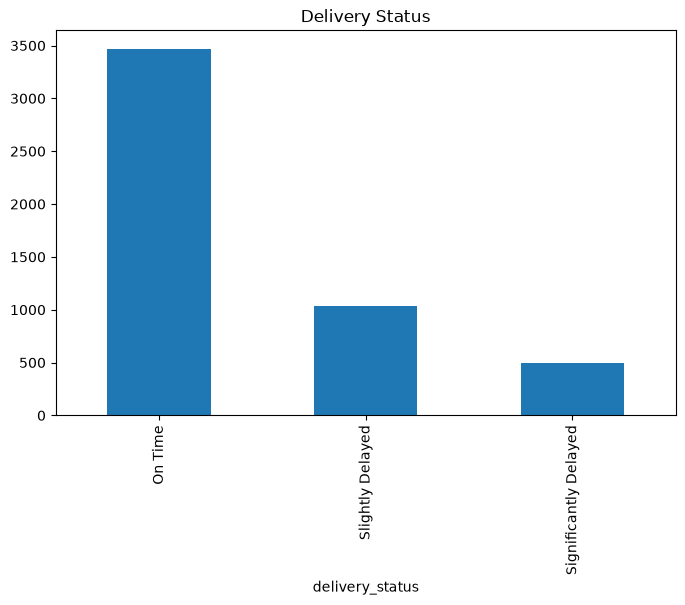

In [82]:
delivery["delivery_status"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Delivery Status"
)

plt.show()

Delivery Time Distribution

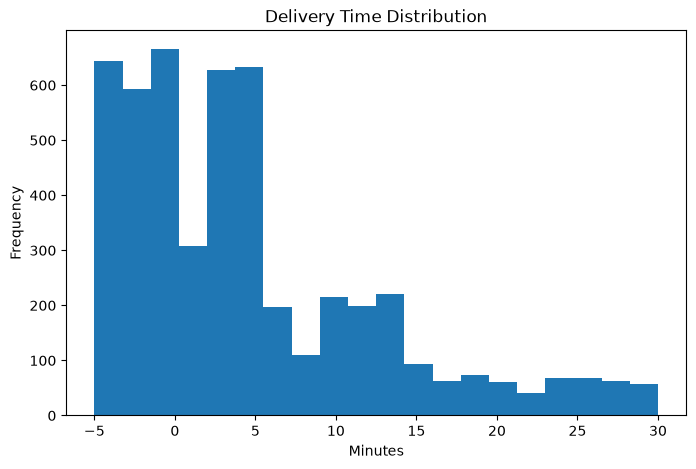

In [83]:
plt.figure(figsize=(8,5))

plt.hist(delivery["delivery_time_minutes"], bins=20)

plt.title("Delivery Time Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")

plt.show()

Distance Box Plot

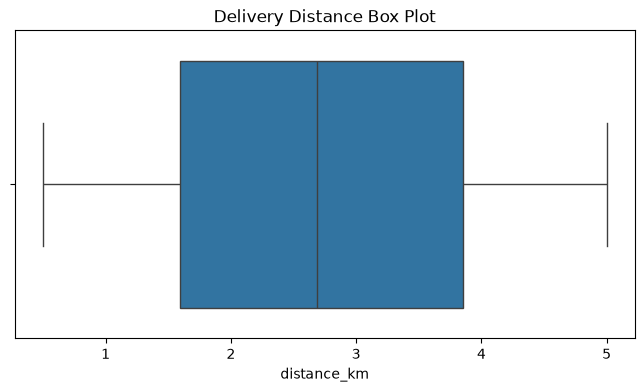

In [84]:
plt.figure(figsize=(8,4))

sns.boxplot(x=delivery["distance_km"])

plt.title("Delivery Distance Box Plot")

plt.show()

Top Delay Reasons

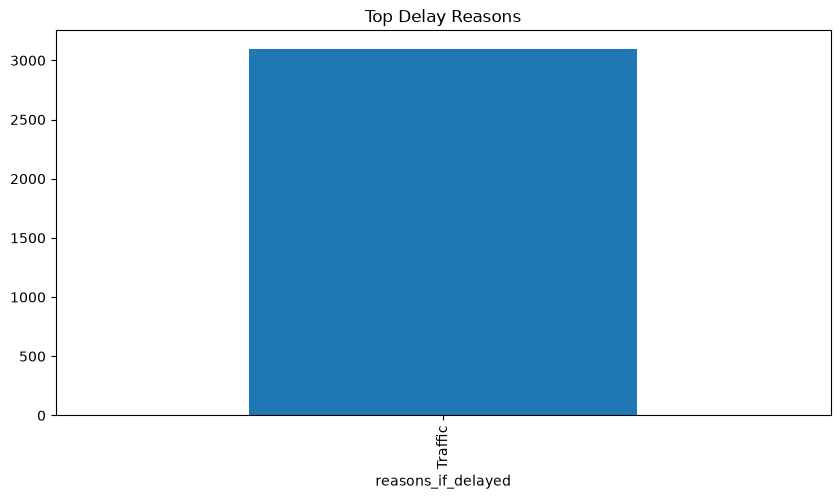

In [85]:
delivery["reasons_if_delayed"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5),
    title="Top Delay Reasons"
)

plt.show()

## Marketing Performance Dataset Overview

This section provides an overview of the marketing performance dataset, including its structure, dimensions, data types, and summary statistics.

In [86]:
marketing.head()

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,New User Discount,2024-11-05,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,390914,Weekend Special,2024-11-05,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,834385,Festival Offer,2024-11-05,Inactive,Email,7012,370,78,4524.23,2621.00,2.95
3,241523,Flash Sale,2024-11-05,Inactive,SMS,1115,579,86,3622.79,2955.00,2.84
4,595111,Membership Drive,2024-11-05,New Users,Email,7172,795,54,2888.99,8951.81,2.22


In [87]:
marketing.info()


<class 'pandas.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   campaign_id        5400 non-null   int64  
 1   campaign_name      5400 non-null   str    
 2   date               5400 non-null   str    
 3   target_audience    5400 non-null   str    
 4   channel            5400 non-null   str    
 5   impressions        5400 non-null   int64  
 6   clicks             5400 non-null   int64  
 7   conversions        5400 non-null   int64  
 8   spend              5400 non-null   float64
 9   revenue_generated  5400 non-null   float64
 10  roas               5400 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 464.2 KB


In [88]:
marketing.shape

(5400, 11)

In [89]:
marketing.describe(include="all")

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
count,5400.000000,5400,5400,5400,5400,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000
unique,NaN,9,600,4,4,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,New User Discount,2024-11-05,New Users,App,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,600,9,1356,1374,NaN,NaN,NaN,NaN,NaN,NaN
mean,501315.219074,NaN,NaN,NaN,NaN,5460.668519,550.767593,55.192222,3022.192267,5961.742106,2.740711
std,287611.524258,NaN,NaN,NaN,NaN,2571.779820,260.080051,26.150173,1148.732680,2322.242911,0.722986
min,243.000000,NaN,NaN,NaN,NaN,1002.000000,100.000000,10.000000,1000.630000,2003.100000,1.500000
25%,249200.000000,NaN,NaN,NaN,NaN,3231.500000,322.000000,32.000000,2029.070000,3907.240000,2.120000
50%,505012.500000,NaN,NaN,NaN,NaN,5457.500000,555.000000,55.000000,3042.485000,5935.940000,2.725000
75%,752219.250000,NaN,NaN,NaN,NaN,7676.250000,772.000000,78.000000,4011.572500,7973.712500,3.370000


## Missing Value Analysis

This step checks whether the marketing dataset contains any missing values.

In [90]:
marketing.isnull().sum()

campaign_id          0
campaign_name        0
date                 0
target_audience      0
channel              0
impressions          0
clicks               0
conversions          0
spend                0
revenue_generated    0
roas                 0
dtype: int64

## Duplicate Record Analysis

This step identifies duplicate records in the marketing dataset.

In [91]:
marketing.duplicated().sum()

np.int64(0)

## Date Conversion

The date column is converted into datetime format for time-based analysis.

In [92]:
marketing["date"] = pd.to_datetime(marketing["date"])


Create Date Features

In [93]:
marketing["Year"] = marketing["date"].dt.year
marketing["Month"] = marketing["date"].dt.month_name()
marketing["Day"] = marketing["date"].dt.day
marketing["Weekday"] = marketing["date"].dt.day_name()

Marketing KPIs

In [94]:
marketing["spend"].sum()

np.float64(16319838.24)

In [95]:
marketing["impressions"].sum()

np.int64(29487610)

In [96]:
marketing["revenue_generated"].sum()

np.float64(32193407.37)

In [97]:
marketing["clicks"].sum()

np.int64(2974145)

In [98]:
marketing["conversions"].sum()

np.int64(298038)

In [99]:
marketing["roas"].mean()

np.float64(2.740711111111111)

Campaign-wise Revenue

Channel-wise Revenue

In [100]:
marketing.groupby("channel")["revenue_generated"] \
         .sum() \
         .sort_values(ascending=False)

channel
Email           8189331.58
App             8075010.49
Social Media    7990415.98
SMS             7938649.32
Name: revenue_generated, dtype: float64

Channel-wise Spend

In [101]:
marketing.groupby("channel")["spend"] \
         .sum() \
         .sort_values(ascending=False)

channel
App             4213378.75
Social Media    4110363.91
SMS             3998607.54
Email           3997488.04
Name: spend, dtype: float64

Target Audience Analysis

In [102]:
marketing["target_audience"].value_counts()

target_audience
New Users    1356
Premium      1355
Inactive     1347
All          1342
Name: count, dtype: int64

Monthly Revenue

In [103]:
marketing.groupby("Month")["revenue_generated"].sum()

Month
April        3170258.15
August       3235917.91
December     1672871.85
February     1587988.12
January      1590007.94
July         3373817.56
June         3237143.38
March        2484465.18
May          3425324.50
November     1856927.63
October      3302872.46
September    3255812.69
Name: revenue_generated, dtype: float64

Revenue by Channel

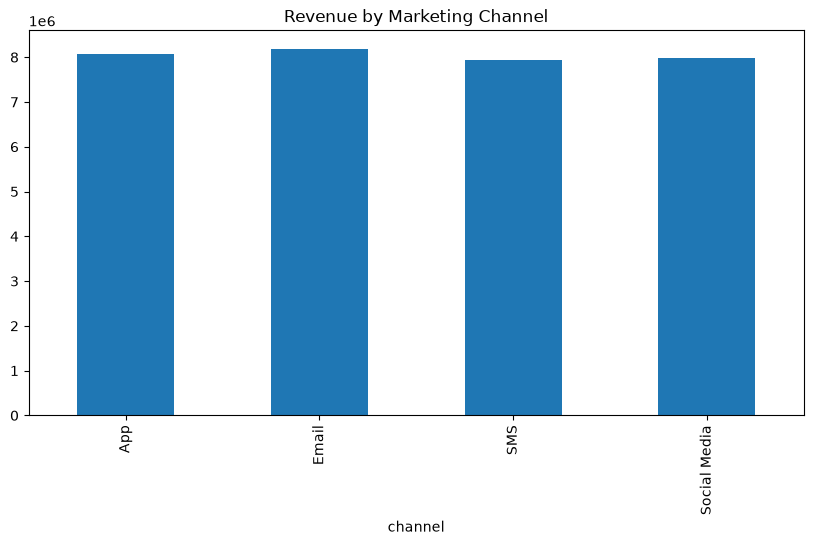

In [104]:
marketing.groupby("channel")["revenue_generated"].sum().plot(
    kind="bar",
    figsize=(10,5),
    title="Revenue by Marketing Channel"
)

plt.show()

Spend by Channel

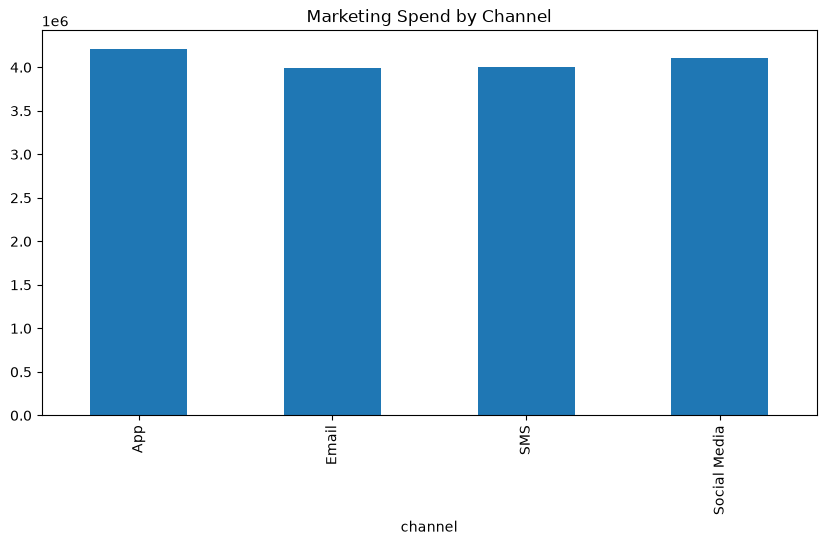

In [105]:
marketing.groupby("channel")["spend"].sum().plot(
    kind="bar",
    figsize=(10,5),
    title="Marketing Spend by Channel"
)

plt.show()

Campaign-wise Revenue

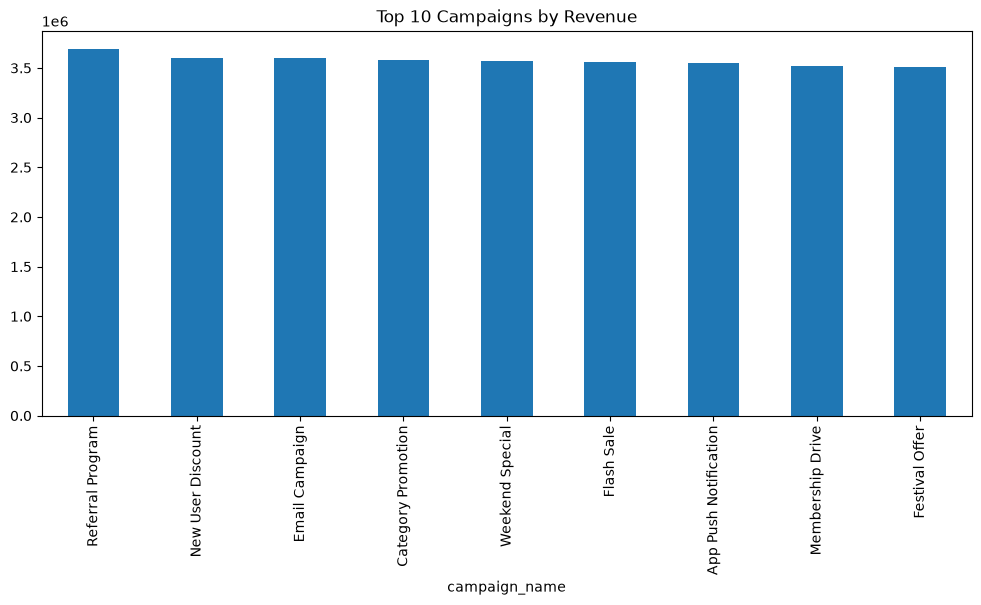

In [106]:
marketing.groupby("campaign_name")["revenue_generated"].sum().nlargest(10).plot(
    kind="bar",
    figsize=(12,5),
    title="Top 10 Campaigns by Revenue"
)

plt.show()

Spend Box Plot

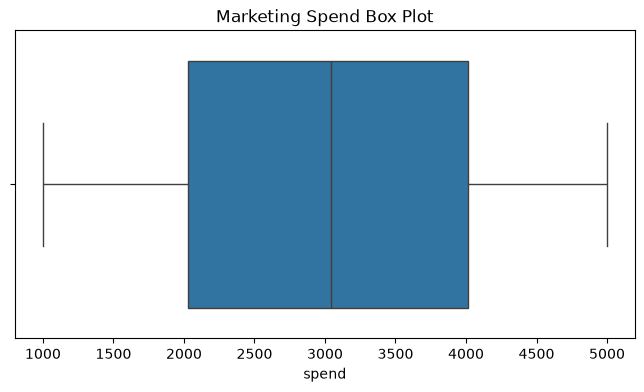

In [107]:
plt.figure(figsize=(8,4))

sns.boxplot(x=marketing["spend"])

plt.title("Marketing Spend Box Plot")

plt.show()

Revenue Box Plot

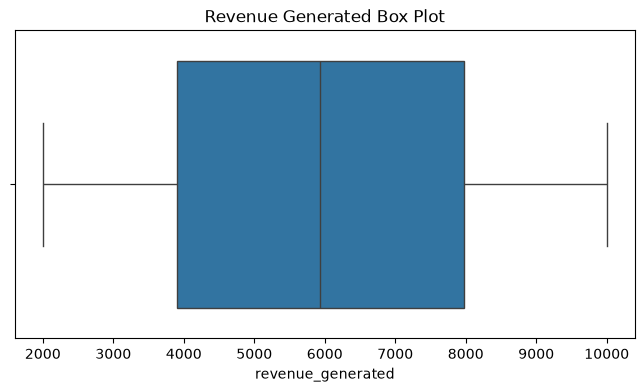

In [108]:
plt.figure(figsize=(8,4))

sns.boxplot(x=marketing["revenue_generated"])

plt.title("Revenue Generated Box Plot")

plt.show()

## Customer Feedback Dataset Overview

This section analyzes customer feedback data to understand customer satisfaction, ratings, feedback categories, and sentiments.

In [109]:
feedback.head()

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date
0,2234710,1961864118,30065862,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17
1,5450964,1549769649,9573071,3,The order was incorrect.,App Experience,Negative,2024-05-28
2,482108,9185164487,45477575,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23
3,4823104,9644738826,88067569,4,The product met my expectations.,App Experience,Neutral,2023-11-24
4,3537464,5427684290,83298567,3,Product was damaged during delivery.,Delivery,Negative,2023-11-20


In [110]:
feedback.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   feedback_id        5000 non-null   int64
 1   order_id           5000 non-null   int64
 2   customer_id        5000 non-null   int64
 3   rating             5000 non-null   int64
 4   feedback_text      5000 non-null   str  
 5   feedback_category  5000 non-null   str  
 6   sentiment          5000 non-null   str  
 7   feedback_date      5000 non-null   str  
dtypes: int64(4), str(4)
memory usage: 312.6 KB


In [111]:
feedback.shape

(5000, 8)

Column Names Check

In [112]:
feedback.columns.tolist()

['feedback_id',
 'order_id',
 'customer_id',
 'rating',
 'feedback_text',
 'feedback_category',
 'sentiment',
 'feedback_date']

## Missing Value Analysis

This step checks missing values present in the customer feedback dataset.

In [113]:
feedback.isnull().sum()

feedback_id          0
order_id             0
customer_id          0
rating               0
feedback_text        0
feedback_category    0
sentiment            0
feedback_date        0
dtype: int64

## Duplicate Record Analysis

This step identifies duplicate feedback records to maintain data quality.

In [114]:
feedback.duplicated().sum()

np.int64(0)

Convert Feedback Date

In [115]:
feedback["feedback_date"].head()

0    2024-07-17
1    2024-05-28
2    2024-09-23
3    2023-11-24
4    2023-11-20
Name: feedback_date, dtype: str

In [116]:
feedback["feedback_date"] = pd.to_datetime(
    feedback["feedback_date"],
    format="mixed",
    dayfirst=True
)

Rating Analysis

In [117]:
feedback["rating"].mean()

np.float64(3.3444)

Rating Count

In [118]:
feedback["rating"].value_counts().sort_index()

rating
1     540
2     538
3    1398
4    1708
5     816
Name: count, dtype: int64

Sentiment Analysis

In [119]:
feedback["sentiment"].value_counts()

sentiment
Neutral     1738
Negative    1642
Positive    1620
Name: count, dtype: int64

In [120]:
feedback["sentiment"].value_counts(normalize=True)*100

sentiment
Neutral     34.76
Negative    32.84
Positive    32.40
Name: proportion, dtype: float64

Top Feedback Categories

In [121]:
feedback["feedback_category"].value_counts().head(10)

feedback_category
Delivery            1271
Customer Service    1266
Product Quality     1250
App Experience      1213
Name: count, dtype: int64

Customer Satisfaction by Rating

In [122]:
feedback.groupby("rating")["feedback_id"].count()

rating
1     540
2     538
3    1398
4    1708
5     816
Name: feedback_id, dtype: int64

Sentiment Chart

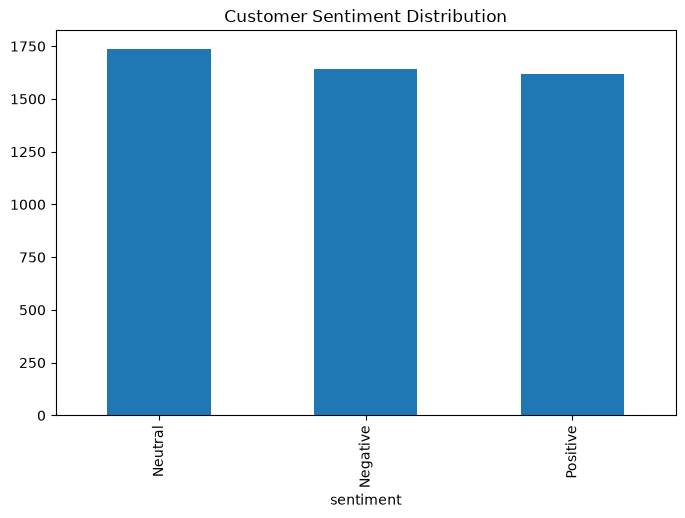

In [123]:
feedback["sentiment"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Customer Sentiment Distribution"
)

plt.show()

Rating Distribution Chart

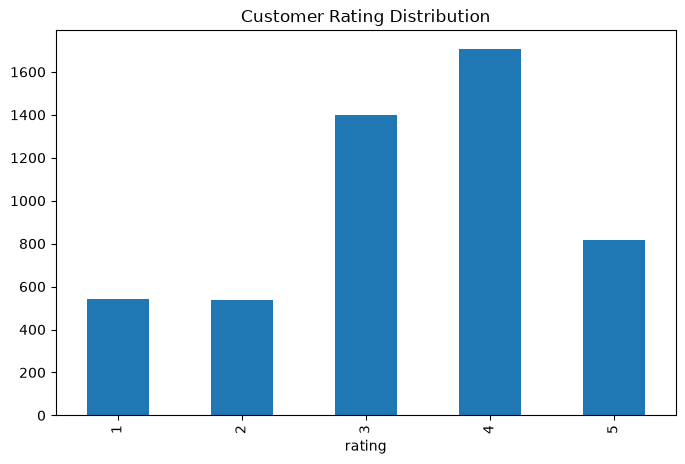

In [124]:
feedback["rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5),
    title="Customer Rating Distribution"
)

plt.show()

Feedback Category Chart

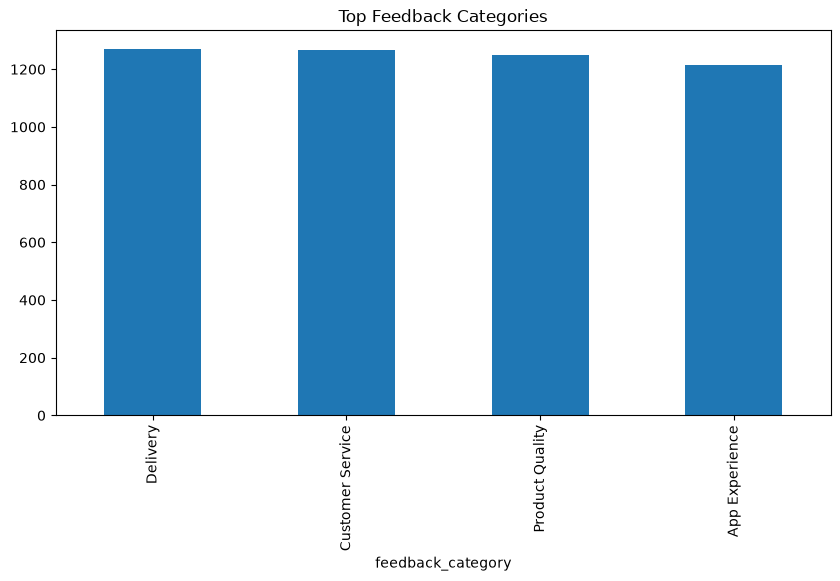

In [125]:
feedback["feedback_category"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5),
    title="Top Feedback Categories"
)

plt.show()

Monthly Feedback Trend

In [126]:
feedback["Year"] = feedback["feedback_date"].dt.year

feedback["Month"] = feedback["feedback_date"].dt.month_name()

In [127]:
feedback.groupby("Month")["feedback_id"].count()

Month
April        448
August       487
December     306
February     289
January      328
July         450
June         453
March        448
May          472
November     310
October      522
September    487
Name: feedback_id, dtype: int64

Save Clean Feedback File

In [128]:
feedback.to_csv(
    "../data/cleaned/customer_feedback_cleaned.csv",
    index=False
)

In [129]:
import os

os.listdir("../data/cleaned")

['customer_feedback_cleaned.csv',
 'delivery_cleaned.csv',
 'inventory_cleaned.csv',
 'marketing_cleaned.csv',
 'orders_full.csv',
 'product_dashboard.csv',
 'sales_dashboard.csv']

In [130]:
customers
orders
order_items
products

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25.0,3,27,55
...,...,...,...,...,...,...,...,...,...,...
263,444361,Pain Reliever,Pharmacy,"Prakash, Bawa and Kale",822.63,1028.29,20.0,365,20,71
264,679284,Cough Syrup,Pharmacy,Pant LLC,877.89,1097.36,20.0,365,28,95
265,240179,Cough Syrup,Pharmacy,Ram-Suri,90.56,113.20,20.0,365,20,56
266,673058,Cough Syrup,Pharmacy,Balan-Madan,765.76,957.20,20.0,365,30,94


In [131]:
print(customers.columns.tolist())
print(orders.columns.tolist())
print(order_items.columns.tolist())
print(products.columns.tolist())

['customer_id', 'customer_name', 'email', 'phone', 'address', 'area', 'pincode', 'registration_date', 'customer_segment', 'total_orders', 'avg_order_value']
['order_id', 'customer_id', 'order_date', 'promised_delivery_time', 'actual_delivery_time', 'delivery_status', 'order_total', 'payment_method', 'delivery_partner_id', 'store_id', 'Year', 'Month', 'Day', 'Weekday', 'Quarter']
['order_id', 'product_id', 'quantity', 'unit_price', 'total_sales']
['product_id', 'product_name', 'category', 'brand', 'price', 'mrp', 'margin_percentage', 'shelf_life_days', 'min_stock_level', 'max_stock_level']


In [132]:
orders_customer = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [133]:
orders_customer.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,...,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,...,Urishilla Hegde,ydeo@example.org,910400446367,"H.No. 330\nRana Path, Sagar 712033",Allahabad,911359,2024-09-02,Regular,13,749.95
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,...,Ranveer Mahal,phegde@example.org,912292591574,"49, Sarkar Zila, Navi Mumbai-077374",Thrissur,856100,2023-11-07,New,5,958.06
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,...,Aarna Bawa,kondajagdish@example.com,912719661653,"14/351, Agarwal Path\nMedininagar 636193",Vellore,117423,2024-01-05,Inactive,4,327.93
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,...,Aayush Sengupta,lekha10@example.com,913367647372,"20/47\nRatta Chowk, Sonipat-022522",Gaya,288459,2023-12-25,Premium,5,273.38
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,...,Vansha Kuruvilla,xalak62@example.com,912910638833,"H.No. 68, Gaba Road\nKhandwa 040880",Asansol,149383,2024-10-02,Premium,14,763.10


In [134]:
orders_items = orders_customer.merge(
    order_items,
    on="order_id",
    how="left"
)

In [135]:
orders_items.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,...,area,pincode,registration_date,customer_segment,total_orders,avg_order_value,product_id,quantity,unit_price,total_sales
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,...,Allahabad,911359,2024-09-02,Regular,13,749.95,642612,3,517.03,1551.09
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,...,Thrissur,856100,2023-11-07,New,5,958.06,378676,1,881.42,881.42
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,...,Vellore,117423,2024-01-05,Inactive,4,327.93,741341,2,923.84,1847.68
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,...,Gaya,288459,2023-12-25,Premium,5,273.38,561860,1,874.78,874.78
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,...,Asansol,149383,2024-10-02,Premium,14,763.10,602241,2,976.55,1953.10


In [136]:
orders_full = orders_items.merge(
    products,
    on="product_id",
    how="left"
)

In [137]:
orders_full.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,...,total_sales,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,...,1551.09,Pet Treats,Pet Care,Pillay-Ahuja,517.03,795.43,35.0,365,16,57
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,...,881.42,Orange Juice,Cold Drinks & Juices,Baral-Kamdar,881.42,1259.17,30.0,180,19,65
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,...,1847.68,Eggs,Dairy & Breakfast,Prasad LLC,923.84,1154.80,20.0,7,13,62
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,...,874.78,Orange Juice,Cold Drinks & Juices,Gupta Ltd,874.78,1249.69,30.0,180,21,90
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,...,1953.10,Nuts,Snacks & Munchies,Bahl-Pau,976.55,1502.38,35.0,90,12,75


In [138]:
orders_full.shape

(5000, 38)

In [139]:
orders_full.columns.tolist()

['order_id',
 'customer_id',
 'order_date',
 'promised_delivery_time',
 'actual_delivery_time',
 'delivery_status',
 'order_total',
 'payment_method',
 'delivery_partner_id',
 'store_id',
 'Year',
 'Month',
 'Day',
 'Weekday',
 'Quarter',
 'customer_name',
 'email',
 'phone',
 'address',
 'area',
 'pincode',
 'registration_date',
 'customer_segment',
 'total_orders',
 'avg_order_value',
 'product_id',
 'quantity',
 'unit_price',
 'total_sales',
 'product_name',
 'category',
 'brand',
 'price',
 'mrp',
 'margin_percentage',
 'shelf_life_days',
 'min_stock_level',
 'max_stock_level']

In [140]:
orders_full = orders_full.drop(
    columns=["Year", "Month", "Day", "Weekday", "Quarter"],
    errors="ignore"
)

In [141]:
orders_full.columns.tolist()

['order_id',
 'customer_id',
 'order_date',
 'promised_delivery_time',
 'actual_delivery_time',
 'delivery_status',
 'order_total',
 'payment_method',
 'delivery_partner_id',
 'store_id',
 'customer_name',
 'email',
 'phone',
 'address',
 'area',
 'pincode',
 'registration_date',
 'customer_segment',
 'total_orders',
 'avg_order_value',
 'product_id',
 'quantity',
 'unit_price',
 'total_sales',
 'product_name',
 'category',
 'brand',
 'price',
 'mrp',
 'margin_percentage',
 'shelf_life_days',
 'min_stock_level',
 'max_stock_level']

In [142]:
orders_full.shape

(5000, 33)

In [143]:
orders_full.to_csv(
    "../data/cleaned/orders_full.csv",
    index=False
)

In [144]:
sales_dashboard = orders_full[
    [
        "order_id",
        "order_date",
        "customer_id",
        "product_id",
        "category",
        "quantity",
        "total_sales",
        "payment_method",
        "delivery_status"
    ]
]

In [145]:
sales_dashboard.head()

,order_id,order_date,customer_id,product_id,category,quantity,total_sales,payment_method,delivery_status
0,1961864118,2024-07-17 08:34:01,30065862,642612,Pet Care,3,1551.09,Cash,On Time
1,1549769649,2024-05-28 13:14:29,9573071,378676,Cold Drinks & Juices,1,881.42,Cash,On Time
2,9185164487,2024-09-23 13:07:12,45477575,741341,Dairy & Breakfast,2,1847.68,UPI,On Time
3,9644738826,2023-11-24 16:16:56,88067569,561860,Cold Drinks & Juices,1,874.78,Card,On Time
4,5427684290,2023-11-20 05:00:39,83298567,602241,Snacks & Munchies,2,1953.10,Cash,On Time


In [146]:
sales_dashboard.shape

(5000, 9)

In [147]:
sales_dashboard["order_date"] = pd.to_datetime(
    sales_dashboard["order_date"],
    format="mixed",
    dayfirst=True
)

In [148]:
sales_dashboard["Year"] = sales_dashboard["order_date"].dt.year

sales_dashboard["Month"] = sales_dashboard["order_date"].dt.month_name()

sales_dashboard["Day"] = sales_dashboard["order_date"].dt.day

In [149]:
sales_dashboard.to_csv(
    "../data/cleaned/sales_dashboard.csv",
    index=False
)

In [150]:
import os

os.listdir("../data/cleaned")

['customer_feedback_cleaned.csv',
 'delivery_cleaned.csv',
 'inventory_cleaned.csv',
 'marketing_cleaned.csv',
 'orders_full.csv',
 'product_dashboard.csv',
 'sales_dashboard.csv']

In [151]:
product_dashboard = orders_full.groupby(
    [
        "product_id",
        "product_name",
        "category",
        "brand"
    ]
).agg(
    total_quantity=("quantity", "sum"),
    total_sales=("total_sales", "sum"),
    total_orders=("order_id", "nunique")
).reset_index()

In [152]:
product_dashboard.head()

,product_id,product_name,category,brand,total_quantity,total_sales,total_orders
0,4452,Baby Wipes,Baby Care,Morar-Mistry,39,6625.32,23
1,6405,Baby Food,Baby Care,Kashyap-Reddy,34,8041.34,18
2,9436,Toothpaste,Personal Care,Naidu PLC,44,3890.92,21
3,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,27,3433.32,15
4,14145,Spinach,Fruits & Vegetables,"Thakur, Shah and Pingle",40,25233.60,21


In [153]:
product_dashboard.shape

(268, 7)

In [154]:
product_dashboard.to_csv(
    "../data/cleaned/product_dashboard.csv",
    index=False
)

In [155]:
import os
os.listdir("../data/cleaned")

['customer_feedback_cleaned.csv',
 'delivery_cleaned.csv',
 'inventory_cleaned.csv',
 'marketing_cleaned.csv',
 'orders_full.csv',
 'product_dashboard.csv',
 'sales_dashboard.csv']

In [156]:
inventory.to_csv(
    "../data/cleaned/inventory_cleaned.csv",
    index=False
)

In [157]:
delivery.head()

,order_id,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status,reasons_if_delayed
0,1961864118,63230,2024-07-17 08:52:01,2024-07-17 08:47:01,-5.0,0.96,On Time,NaN
1,1549769649,14983,2024-05-28 13:25:29,2024-05-28 13:27:29,2.0,0.98,On Time,Traffic
2,9185164487,39859,2024-09-23 13:25:12,2024-09-23 13:29:12,4.0,3.83,On Time,Traffic
3,9644738826,61497,2023-11-24 16:34:56,2023-11-24 16:33:56,-1.0,2.76,On Time,NaN
4,5427684290,84315,2023-11-20 05:17:39,2023-11-20 05:18:39,1.0,2.63,On Time,Traffic


In [158]:
delivery.to_csv(
    "../data/cleaned/delivery_cleaned.csv",
    index=False
)

In [159]:
marketing.to_csv(
    "../data/cleaned/marketing_cleaned.csv",
    index=False
)

# Final Output

## Cleaned Datasets Created

- orders_full.csv
- sales_dashboard.csv
- product_dashboard.csv
- inventory_cleaned.csv
- delivery_cleaned.csv
- marketing_cleaned.csv
- customer_feedback_cleaned.csv

## Project Status

✔ Data Cleaning Completed

✔ Cleaned Datasets Generated

✔ Data Imported into PostgreSQL

✔ SQL Analysis Completed

✔ Primary Keys and Foreign Keys Created

✔ Views and Indexes Created

✔ Python EDA Started

The remaining analysis and visualizations are implemented using Python (.py) scripts.

**End of Data Cleaning Notebook**